**Disciplina: ACA052 - Meteorologia Sinótica I**

Monitor: Ronald Guiuseppi Ramírez Nina

File: Aula_07.ipynb

# **Imagens de Satélite e Modelo Global Forecast System (GFS)**

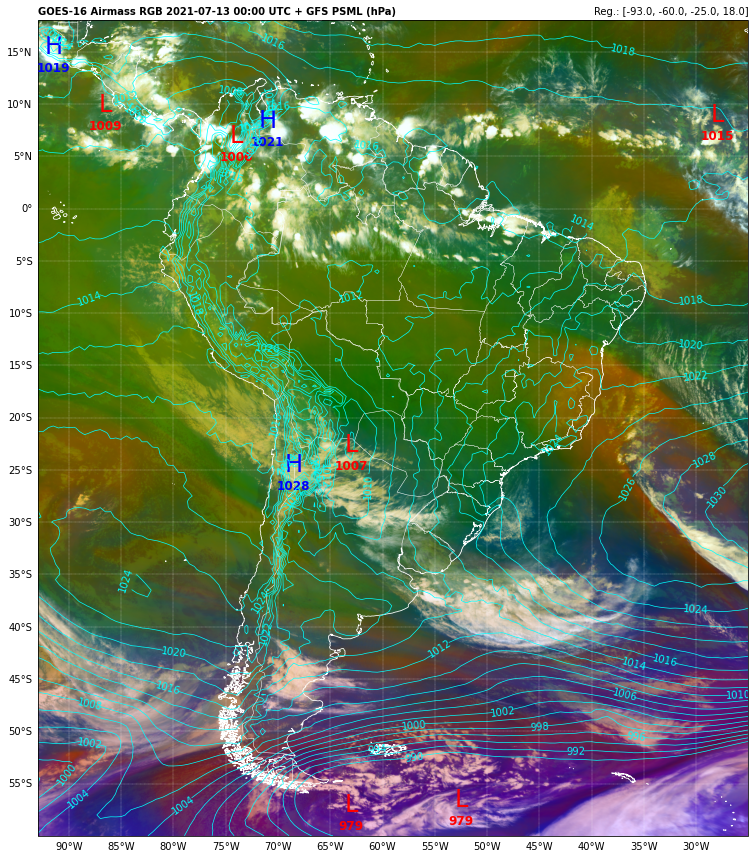

# **Instalando pacotes para o processamento dos dados grib**

In [ ]:
# Instalando o cartopy, com os pacotes e versões necessárias para o seu bom funcionamento no colab
!pip uninstall -y shapely
!pip install -q netcdf4
!pip install shapely cartopy --no-binary shapely --no-binary cartopy

Found existing installation: Shapely 1.8.2
Uninstalling Shapely-1.8.2:
  Successfully uninstalled Shapely-1.8.2
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 198 kB 5.0 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 10.8 MB 42.7 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
     |████████████████████████████████| 10.8 MB 1.9 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
     |████████████████████████████████| 10.8 MB 1.2 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
     |████████████████████████████████| 12.1 MB 4.6 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing whee

**Instalando o pygrib**

In [ ]:
# Instalando o pacote "pygrib"
!pip install pygrib

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


**Objetivos**

- Fazer download de imagens de satélite do **GOES-16** do repositório do **Amazon**.
- Fazer mapas com imagens de satélite do **GOES-16**.
- Fazer mapas com a imagem de satélite **GOES-16** mais o Modelo Numérico **GFS**.
- Trazar as cristas e cavados.

**Importando pacotes de processameto e geração de mapas**

In [ ]:
print("1. Importar pacotes")
# Pacotes de processamento de dados 
import numpy as np
# Pacote para ler e processar dados grib
import pygrib
# Pacote para abrir o arquivo netcdf
from netCDF4 import Dataset

# Pacotes para gerar mapas
import matplotlib.pyplot as plt
import cartopy.crs as ccrs # Pacote para mapas (sistema de referência cooordenado)
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Importar o drive para acesso aos dados
print("2. Importar drive")
from google.colab import drive
drive.mount('/content/drive')

print("3. Terminou de importar os pacotes")

1. Importar pacotes
2. Importar drive
Mounted at /content/drive
3. Terminou de importar os pacotes


# **Fazendo download e upload de imagens de satélite do GOES-R (file .nc)**

Para fazer o download de imagens de satélite do **GOES-R** no formato **.nc** acessar ao seguinte link:

https://home.chpc.utah.edu/~u0553130/Brian_Blaylock/cgi-bin/goes16_download.cgi



Elegir as seguinte opções para o download da imagem de satélite:

- **Source**: AWS
- **Satellite**: **GOES-16/East** ou GOES-17/West
- **Domain**: Full Disk
- **Product**: ABI L2 Cloud and Moisture Imagery
- **Date**: DD/MM/YYYY (de seu interesse de análise)
- **Hour (UTC)**: 12 (também de seu interesse)

Fazer clic em **Submit** e depois fazer o download do arquivo da **Band 13** (Canal Infravermelho 10.3 um), fazer clic nos quadrados azul com os minutos de seu interesse. 

O seguinte exemplo da imagem tem como exemplo arquivos do **GOES-16 para a data do 17 de julho de 2019 às 12:00 UTC**

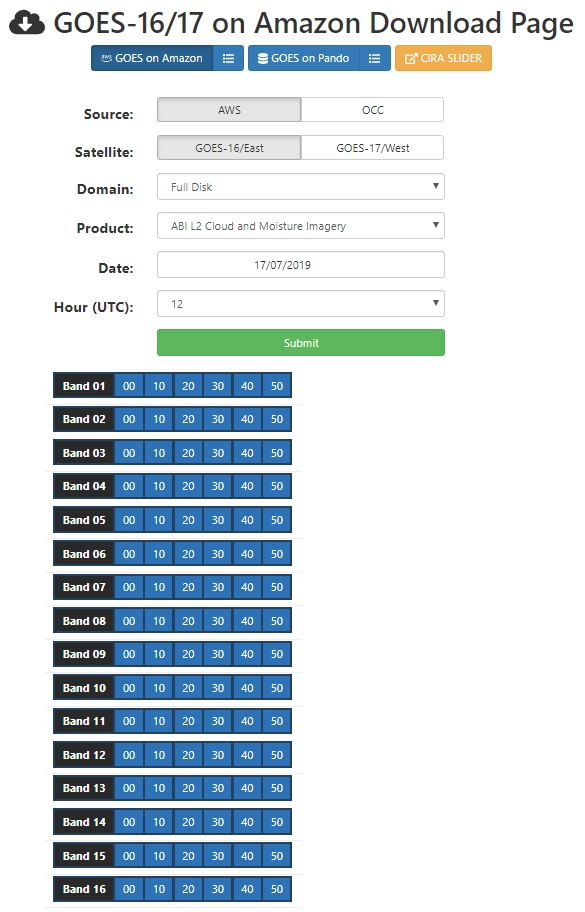

Finalmente um arquivo **NetCDF** vai ser descargado em seu computador. O seguinte passo é fazer o upload desse arquivo **NetCDF** (imagem de satelite da Banda 13) para a sua pasta de trabalho do **Google Drive**. Fazer o código para a visualização da imagem utilizando o **Python**. 

In [ ]:
# Salvar o path do arquivo da imagem de satelite da Band 13
path_sat = '/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_07/OR_ABI-L2-CMIPC-M6C13_G16_s20221601201181_e20221601203566_c20221601204048.nc'

# Abrir a imagem do GOES-16
print("1. Abrindo o arquivo da imagem de satelite")
file_sat = Dataset(path_sat)

file_sat


1. Abrindo o arquivo da imagem de satelite


<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    naming_authority: gov.nesdis.noaa
    Conventions: CF-1.7
    Metadata_Conventions: Unidata Dataset Discovery v1.0
    standard_name_vocabulary: CF Standard Name Table (v35, 20 July 2016)
    institution: DOC/NOAA/NESDIS > U.S. Department of Commerce, National Oceanic and Atmospheric Administration, National Environmental Satellite, Data, and Information Services
    project: GOES
    production_site: NSOF
    production_environment: OE
    spatial_resolution: 2km at nadir
    orbital_slot: GOES-East
    platform_ID: G16
    instrument_type: GOES R Series Advanced Baseline Imager
    scene_id: CONUS
    instrument_ID: FM1
    dataset_name: OR_ABI-L2-CMIPC-M6C13_G16_s20221601201181_e20221601203566_c20221601204048.nc
    iso_series_metadata_id: 8c9e8150-3692-11e3-aa6e-0800200c9a66
    title: ABI L2 Cloud and Moisture Imagery
    summary: Single emissive band Cloud and Moisture Imagery Products are d

Extraindo a matrix com os valores dos pixels da imagem de satelite

In [ ]:
# Obtendo os valores dos pixels da variável CMI
print("2. Obter a matrix com os valores dos pixels")
sat_B13 = file_sat.variables['CMI'][:] 

sat_B13

2. Obter a matrix com os valores dos pixels


masked_array(
  data=[[--, --, --, ..., 270.6614685058594, 270.6614685058594,
         270.6614685058594],
        [--, --, --, ..., 270.6614685058594, 270.60003662109375,
         270.6614685058594],
        [--, --, --, ..., 270.6614685058594, 270.6614685058594,
         270.60003662109375],
        ...,
        [291.6170654296875, 294.01373291015625, 294.6282653808594, ...,
         293.8908386230469, 293.9523010253906, 293.8908386230469],
        [290.69525146484375, 294.1981201171875, 294.3824768066406, ...,
         293.8908386230469, 293.7679443359375, 293.8293762207031],
        [290.7567138671875, 293.9523010253906, 293.9523010253906, ...,
         293.8908386230469, 293.8293762207031, 293.8293762207031]],
  mask=[[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ...,

Extraíndo alguns metadatos da imagem de satelite:

- Tempo de cobertura inicial
- Tempo de cobertura final

Criar uma variável do tipo **string** armazenando a data e hora da imagem de satelite

In [ ]:
# Extraíndo alguns metadatos da imagem de satelite

# Tempo de cobertura inicial
print("3. Tempo de cobertura inicial")
time_start = file_sat.time_coverage_start[:]
print(time_start)
# Tempo de cobertura final
print("4. Tempo de cobertura final")
time_end = file_sat.time_coverage_end[:]
print(time_end)

# Extraindo o ano, mes e dia da imagem de satelite
print("5. Extraindo a data da imagem de satelite YYYY-MM-DD")
time_day = file_sat.time_coverage_start[0:10]
print(time_day)
# Extraindo a hora da imagem de satelite
print("6. Extraindo a hora da imagem de satelite")
time_hour = file_sat.time_coverage_start[11:16]
print(time_hour)

# Criando o objeto da data e hora do satelite
print("7. Data e hora da imagem - YYYY-MM-DD HH:MM UTC")
data_satelite = time_day + ' ' + time_hour + ' UTC'
data_satelite

3. Tempo de cobertura inicial
2022-06-09T12:01:18.1Z
4. Tempo de cobertura final
2022-06-09T12:03:56.6Z
5. Extraindo a data da imagem de satelite YYYY-MM-DD
2022-06-09
6. Extraindo a hora da imagem de satelite
12:01
7. Data e hora da imagem - YYYY-MM-DD HH:MM UTC


'2022-06-09 12:01 UTC'

Criando o mapa com a imagem de satelite

8. Criando a Figura onde fazer o mapa
9. Utilizando a projeção PlateCarree para o mapa
10. Estabelecendo a extensão do mapa
11. Estabelecendo a extensão Geostacionaria
12. Agregando linhas de grande, de costa, bordas entre paises, etc
13. Plot da imagem de satelite
14. Agregando a paleta de cor em cinza
15. Agregando titulo ao nosso mapa


/usr/local/lib/python3.7/dist-packages/cartopy/crs.py:228: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  if len(multi_line_string) > 1:
/usr/local/lib/python3.7/dist-packages/cartopy/crs.py:280: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for line in multi_line_string:
/usr/local/lib/python3.7/dist-packages/cartopy/crs.py:347: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  if len(p_mline) > 0:


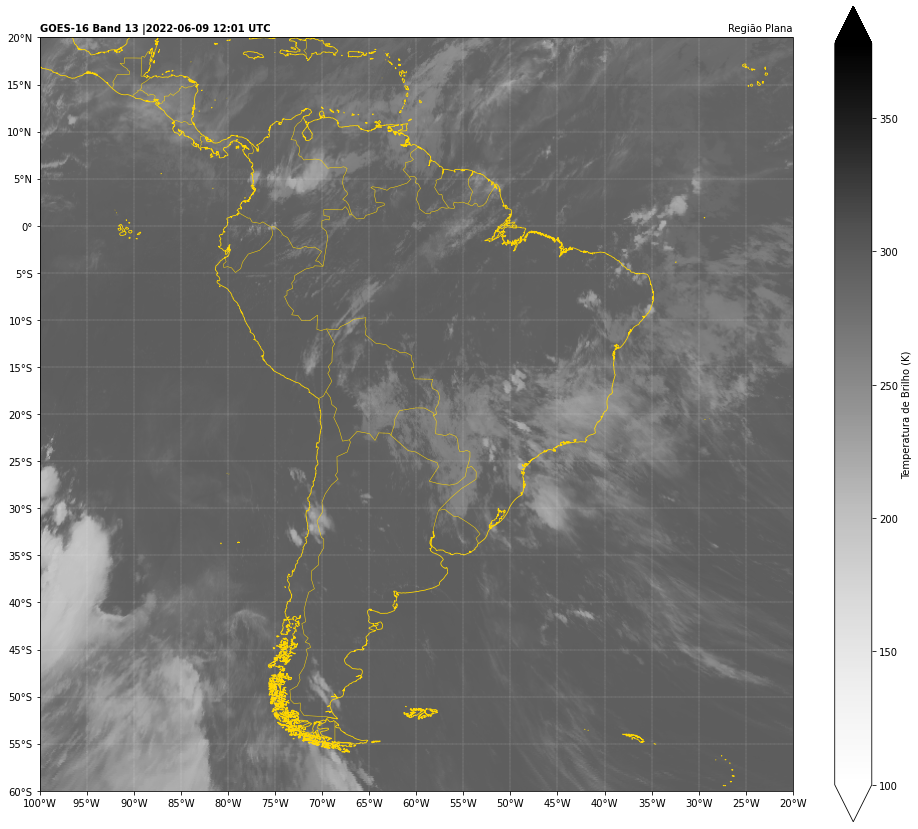

In [ ]:
# Configurar o tamanho da figura
print("8. Criando a Figura onde fazer o mapa")
plt.figure(figsize = (15,15))

# Fazendo a projeção PlateCarree (ciclindrica equidistante)
print("9. Utilizando a projeção PlateCarree para o mapa")
ax = plt.axes(projection = ccrs.PlateCarree(central_longitude = -75.0))

# Extensão do mapa
print("10. Estabelecendo a extensão do mapa")
lat_min = -60
lat_max = 20
lon_min = -100
lon_max = -20
extent = [lon_min, lat_min, lon_max, lat_max]
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], crs = ccrs.PlateCarree())

# Extensão Geostacionaria
print("11. Estabelecendo a extensão Geostacionaria")
img_extent = (-5434894.67527, 5434894.67527, -5434894.67527, 5434894.67527)

# CONFIGURANDO O MAPA COM LINHAS DE GRADE, FORMATANDO OS EIXOS, LINHAS DE COSTA, ETC
print("12. Agregando linhas de grande, de costa, bordas entre paises, etc")
# Agregando linhas de costa
ax.coastlines(resolution = '10m', color = 'gold', linewidth = 0.8)
# Agregando bordes entre paises
ax.add_feature(cfeature.BORDERS, edgecolor='gold', linewidth=0.5)
# Configurando os eixos
xticks = np.arange(lon_min, lon_max + 5, 5)
yticks = np.arange(lat_min, lat_max + 5, 5) 
ax.set_xticks(xticks, crs = ccrs.PlateCarree())
ax.set_yticks(yticks, crs = ccrs.PlateCarree())
# Formatando os eixos
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
# Agregar linhas de grade
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=0.75, linestyle='--', linewidth=0.25,\
                  xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=False)
# Apagando as etiquetas de grade da parte sueperior
gl.top_labels = False
# Apagando as etiquetas de grade do lado direito
gl.right_labels = False

# Plot da imagem
print("13. Plot da imagem de satelite")
img = ax.imshow(sat_B13, vmin= 100, vmax= 378, origin='upper', extent=img_extent, cmap='Greys',\
                transform=ccrs.Geostationary(central_longitude=-75.0))

# Agregando a paleta de cor
print("14. Agregando a paleta de cor em cinza")
plt.colorbar(img, label='Temperatura de Brilho (K)', extend='both', pad=0.05, fraction=0.05)

# Agregar titulo
print("15. Agregando titulo ao nosso mapa")
plt.title('GOES-16 Band 13 |' + data_satelite, fontweight='bold', fontsize=10, loc='left')
plt.title('Região Plana', fontsize=10, loc='right')

# Show the image
plt.show()

**Acessando ao website do GFS para fazer o download dos dados de análise ou previsão**

O primer passo é acessar ao seguinte link:

https://nomads.ncep.noaa.gov/

Ou escrever no buscado de www.google.com o seguinte: **gfs nomads data** e fazer clic na primeira opção

In [ ]:
print("1. Ler arquivo grib")
# Salvar o path do arquivo grib em um objeto --> "path"
path = '/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_07/gfs.t12z.pgrb2full.0p50.f000'
# Ler o arquivo grib 
gfs = pygrib.open(path)

# Mostrar a lista de variáveis do nosso arquivo grib
print("2. Lista de variáveis do arquivo grib")
print('                         ')
print('--------------------------------------------------------------------------------------------------')
f = open("variables.txt", "w")

for variables in gfs:
  print(variables)
  print(variables, file=f)
f.close()

**Ver os index para cada nível vertical de uma variável**

In [ ]:
# Olhando os index para cada nível na varíavel de Altura geopotencial
hgt = gfs.select(name = 'Geopotential Height')
print("3. Ver os index dos níveis de pressão")
hgt

3. Ver os index dos níveis de pressão


[4:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 20000 Pa:fcst time 0 hrs:from 202206091200,
 20:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 25000 Pa:fcst time 0 hrs:from 202206091200,
 36:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 30000 Pa:fcst time 0 hrs:from 202206091200,
 52:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 40000 Pa:fcst time 0 hrs:from 202206091200,
 68:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 50000 Pa:fcst time 0 hrs:from 202206091200,
 84:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 60000 Pa:fcst time 0 hrs:from 202206091200,
 100:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 70000 Pa:fcst time 0 hrs:from 202206091200,
 116:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 75000 Pa:fcst time 0 hrs:from 202206091200,
 132:Geopotential Height:gpm (instant):regular_ll:isobaricInhPa:level 80000 Pa:fcst time 0 hrs:

**Fazendo mapas com a Altura Geopotencial nos níveis de 850 hPa, 500 hPa, 250 hPa**

Criando variáveis (ou objetos) do **hgt** para os níveis de 850 hPa, 500 hPa e 250 hPa. 

- Nível de 850 hPa -> **hgt_850**
- Nível de 500 hPa -> **hgt_500**
- Nível de 250 hPa -> **hgt_250**

**Criando a Figura: Imagen de Satélite GOES - 16 mais o Modelo Numérico GFS**

1. Criando variáveis para cada nível de pressão
2. Obter informalções do arquivo grib
Init: 2022-06-09 12:00:00UTC
Run: 12Z
Forecast: +0
Valid: 2022-06-09 12:00:00 UTC
3. Seleccionar extensão do mapa
4. Ler o dado sobre a região especificada - América do Sul
5. Criar a Figura
6. Asignar projeção ao mapa
7. Agregando linhas de costa, límites entre paises e linhas de grade
8. Agregando os estado de Brasil, The USA, e outros paises
9. Plot da imagem de satelite
10 Fazendo o plot do vento
11. Agregando intervalos de contorno
12. Fazendo plot da altura geopotencial
13. Agregando titulo ao mapa
14. Critério de localização do jato
15. Salavando a figura .png


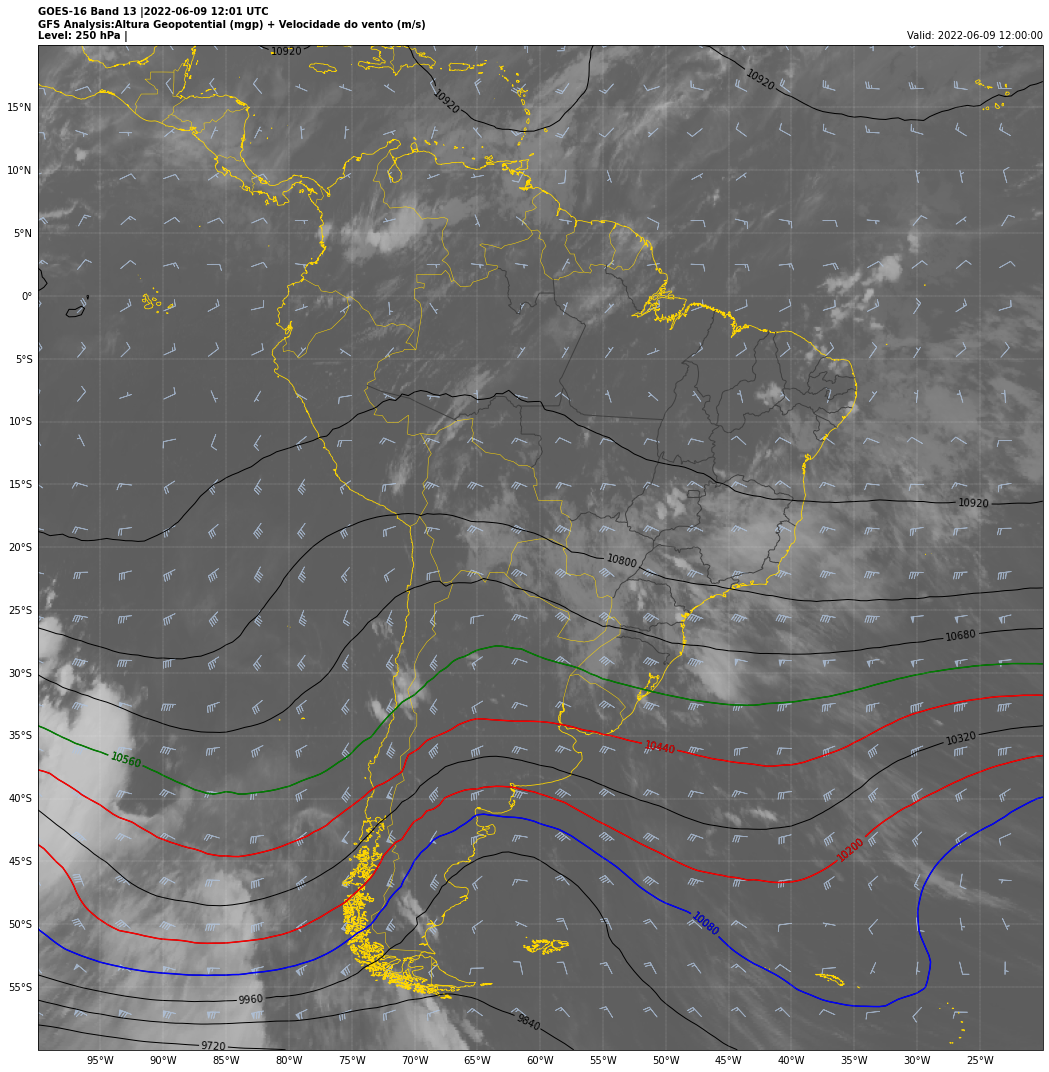

In [ ]:
# Criando as variáveis de hgt para cada nível de pressão
print("1. Criando variáveis para cada nível de pressão")

# Nível de 250 hPa
hgt_250 = gfs.select(name = "Geopotential Height")[1]
u_250 = gfs.select(name = "U component of wind")[1]
v_250 = gfs.select(name = "V component of wind")[1]

# Obter informações do arquivo
print("2. Obter informalções do arquivo grib")
init  = str(hgt_250.analDate)        # Init date / time
run   = str(hgt_250.hour).zfill(2)   # Run
ftime = str(hgt_250.forecastTime)    # Forecast hour
valid = str(hgt_250.validDate)       # Valid date / time
print('Init: ' + init + 'UTC')
print('Run: ' + run + 'Z')
print('Forecast: +' + ftime)
print('Valid: ' + valid + ' UTC')

# Seleccionar a extensão do mapa
print("3. Seleccionar extensão do mapa")
lat_min = -60
lat_max = 20
lon_min = -100
lon_max = -20
# Extensão do mapa
extent = [lon_min, lat_min, lon_max, lat_max]

# Ler o dado e extrair informação sobre a região especificada
print("4. Ler o dado sobre a região especificada - América do Sul")
# Nível de 850
u_250, lats, lons = u_250.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0] + 360, lon2 = extent[2] + 360)
# Nível de 500
v_250, lats, lons = v_250.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0] + 360, lon2 = extent[2] + 360)
# Nível de 250
hgt_250, lats, lons = hgt_250.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0] + 360, lon2 = extent[2] + 360)

# Criando a variável de velocidade do vento
wspd_250 = (u_250**2 + v_250**2)**0.5

# ----------------------------------------------------------------------------------------------------------------
# Crian uma figura
print("5. Criar a Figura")
fig, ax = plt.subplots(figsize=(15,15), subplot_kw={'projection':ccrs.PlateCarree()}, sharey=True)

# FAZENDO O PRIMER MAPA PARA O NÍVEL DE 850 hPa

# ***********************************************************************************************************
# TODO MAPA PRECISA DE ESSA PARTE DE FORMATAÇÃO DE EIXOS, AGREGAR LINHAS DE COSTA, BORDAS ENTRE OS LÍMITES
# DOS PAISES, EXTENSÃO DO MAPA, LINHAS DE GRADE E OUTROS

# Asignar una projeção ao nosso mapa
# PlateCarre() <- Projeção cilíndrica equidistante (Quase parecido ao Proj. Mercator)
print("6. Asignar projeção ao mapa")
ax = plt.axes(projection = ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Definir a extensão do mapa
# Extensão Geostacionaria
img_extent = (-5434894.67527, 5434894.67527, -5434894.67527, 5434894.67527)

print("7. Agregando linhas de costa, límites entre paises e linhas de grade")
# Fazenddo o eixo X no formato de Latitude ºW <- .xaxis.set_major_formatter()
ax.xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS <- .yaxis.set_major_formatter()
ax.yaxis.set_major_formatter(LongitudeFormatter())
# Agregar linhas de costa
ax.coastlines(resolution='10m', color='gold', linewidth=0.8)
# Agregar os límites entre paises
ax.add_feature(cfeature.BORDERS, edgecolor='gold', linewidth=0.5)
# Agregar linhas de grade
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=0.75, linestyle='--', linewidth=0.25,\
                  xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
# Apagando as etiquetas de grade da parte sueperior
gl.top_labels = False
# Apagando as etiquetas de grade do lado direito
gl.right_labels = False

print("8. Agregando os estado de Brasil, The USA, e outros paises")
# Agregando os estados do Brasil (mas também agrega os ecb = ax.set_title('Mapa só com a opção [contourf]', size = 22)
# Lembrar da função <- .cfeature.NaturalEarthFeature()
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
# Agregar os estados do Brasil No primer plot <- .add_feature()
ax.add_feature(states_provinces, edgecolor='0.25')
# *********************************************************************************************************

# FAZENDO O PLOT DA IMAGEM DE SATELITE
print("9. Plot da imagem de satelite")
img = ax.imshow(sat_B13, vmin= 100, vmax= 378, origin='upper', extent=img_extent, cmap='Greys',\
                transform=ccrs.Geostationary(central_longitude=-75.0))

# FAZENDO O PLOT DO VENTO NOS FORMATO DE BARBELAS E VETOR
print("10 Fazendo o plot do vento")

# Plot da variável velocidade do vento em 250 hPa maior ou igual 30ms
#vento_vetor = ax.quiver(lons[::5,::5], lats[::5,::5], u_250[::5,::5], v_250[::5,::5], color='white')

# Create a flag to determine which barbs are flipped
flip_flag = np.zeros((u_250.shape[0],u_250.shape[1]))

# All flags below the equator will be flipped
flip_flag[lats < 0] = 1

# Plot do vento no formato de barbelas
vento_barbela = ax.barbs(lons[::7,::7], lats[::7,::7], u_250[::7,::7], v_250[::7,::7],\
                length = 5.0, alpha = 0.75,sizes = dict(emptybarb=0.0, spacing=0.2, height=0.5),\
                linewidth=0.8, pivot='middle', barbcolor='lightsteelblue', flip_barb = flip_flag[::7,::7])

# -----------------------------------------------------------------------------------------------------------------------
# Definindo intervalos de contorno
print("11. Agregando intervalos de contorno")
hgt_250min = 9000
hgt_250max = 11000
interval = 120
levels = np.arange(hgt_250min, hgt_250max, interval)

# plot da altura geopotencial em 250 hPa
print("12. Fazendo plot da altura geopotencial")
img_250 = ax.contour(lons, lats, hgt_250, colors = 'black', linestyles = 'solid',linewidths = 1, levels = levels)
ax.clabel(img_250, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'black')

# Agregando titulo ao mapa
print("13. Agregando titulo ao mapa")
ax.set_title('GOES-16 Band 13 |' + data_satelite + \
             '\nGFS Analysis:Altura Geopotential (mgp) + Velocidade do vento (m/s)\nLevel: 250 hPa |',\
             fontweight='bold', fontsize=10, loc='left')
ax.set_title('Valid: ' + valid, fontsize=10, loc='right')

# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# FAZENDO ISOHIPSAS PARA A LOCALIZAÇÃO DO JATO

print("14. Critério de localização do jato")
# Jato Polar Norte    -> [10200 mgp - 10440 mgp]
hgt_polar_norte = np.arange(10200, 10441, 240)
JPN = ax.contour(lons, lats, hgt_250, colors = 'red', linestyles = 'solid', linewidths = 1.5, levels = hgt_polar_norte)
ax.clabel(JPN, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'red')

# Jato Polar Sur      -> Menor ou igual 10080 mgp 
hgt_polar_sul = np.arange(10080, 10081, 100)
JPS = ax.contour(lons, lats, hgt_250, colors = 'blue', linestyles = 'solid', linewidths = 1.5, levels = hgt_polar_sul)
ax.clabel(JPS, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'blue')

# Jato Subtropical    -> Maior ou igual 10560 mgp
hgt_subtropical = np.arange(10560, 10561, 100)
JST = ax.contour(lons, lats, hgt_250, colors = 'green', linestyles = 'solid', linewidths = 1.5, levels = hgt_subtropical)
ax.clabel(JST, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'green')

# Menos espaços em branco
fig.tight_layout()

print("15. Salavando a figura .png")
fig.savefig('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_07/Satelite_hgt250_' + f'{init}.png', format='png', dpi = 100)

# **Atividade**

Criar um mapa com a imagem de satélite da Banda 13 de fundo mais os campos das variáveis meteorlógicos do modelo numérico GFS. Seguir as seguintes indicações:

- Imagem de satélite GOES-16 Banda 13
- Pressão Reduzida ao Nível Médio do Mar em linhas sólidas e cor preto.
- Espessura da camada entre 1000 - 500 hPa em linhas discontinuas e cor vermelho. 


**Nota**:

Para a espessura primeiro definir as variáveis **hgt_1000** (com a informação da altura geopotencial no nível de 1000 hPa) e **hgt_500** (com a informação da altura geopotencial no nível de 500 hPa) e depois criar uma variável:

 **espessura = hgt_500 - hgt_1000**


1. Criando variáveis para cada nível de pressão
2. Obter informalções do arquivo grib
Init: 2022-06-09 12:00:00UTC
Run: 12Z
Forecast: +0
Valid: 2022-06-09 12:00:00 UTC
3. Seleccionar extensão do mapa
4. Ler o dado sobre a região especificada - América do Sul
5. Criar a Figura
6. Asignar projeção ao mapa
7. Agregando linhas de costa, límites entre paises e linhas de grade
8. Agregando os estado de Brasil, The USA, e outros paises
9. Plot da imagem de satelite
10 Fazendo o plot do vento
11. Agregando intervalos de contorno
12. Fazendo plot da altura geopotencial
13. Definindo intervalos para os contornos de nossa varíavel
14. Fazendo o plot da variável
15. Agregando titulo ao mapa
16. Salavando a figura .png


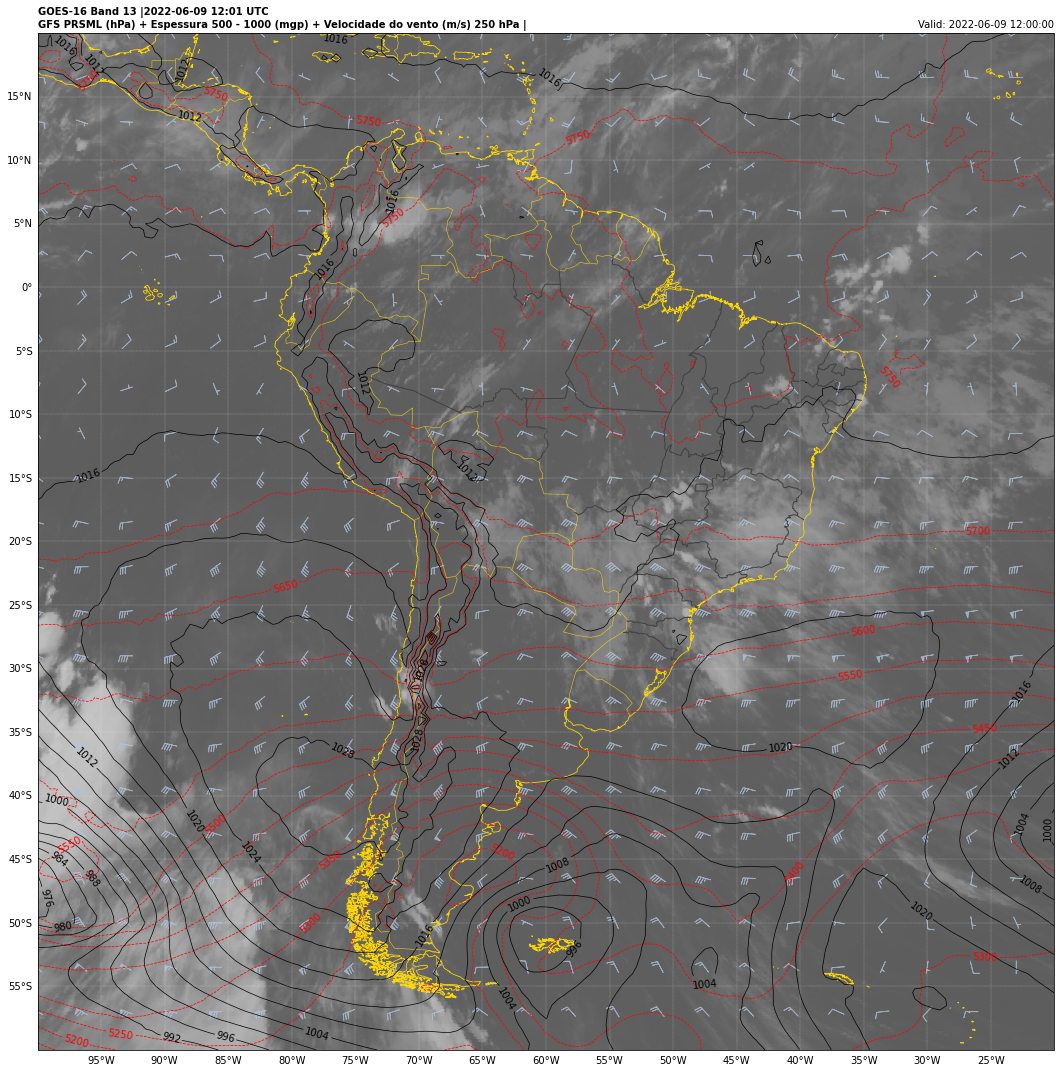

In [ ]:
# Criando as variáveis de hgt para cada nível de pressão
print("1. Criando variáveis para cada nível de pressão")

# Nível de 1000 hPa
hgt_1000 = gfs.select(name = "Geopotential Height")[12]
# Nível de 500 hPa
hgt_500 = gfs.select(name = "Geopotential Height")[4]
# Nivel de 250 hPa
u_250 = gfs.select(name = "U component of wind")[1]
v_250 = gfs.select(name = "V component of wind")[1]
# Pressure reduced to MSL
mslp = gfs.select(name = 'Pressure reduced to MSL')[0]

# Obter informações do arquivo
print("2. Obter informalções do arquivo grib")
init  = str(hgt_500.analDate)        # Init date / time
run   = str(hgt_500.hour).zfill(2)   # Run
ftime = str(hgt_500.forecastTime)    # Forecast hour
valid = str(hgt_500.validDate)       # Valid date / time
print('Init: ' + init + 'UTC')
print('Run: ' + run + 'Z')
print('Forecast: +' + ftime)
print('Valid: ' + valid + ' UTC')

# Seleccionar a extensão do mapa
print("3. Seleccionar extensão do mapa")
lat_min = -60
lat_max = 20
lon_min = -100
lon_max = -20
# Extensão do mapa
extent = [lon_min, lat_min, lon_max, lat_max]

# Ler o dado e extrair informação sobre a região especificada
print("4. Ler o dado sobre a região especificada - América do Sul")
# Nível de 250
u_250, lats, lons = u_250.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0] + 360, lon2 = extent[2] + 360)
# Nível de 250
v_250, lats, lons = v_250.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0] + 360, lon2 = extent[2] + 360)
# Nível de 1000
hgt_1000, lats, lons = hgt_1000.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0] + 360, lon2 = extent[2] + 360)
# Nível de 500
hgt_500, lats, lons = hgt_500.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0] + 360, lon2 = extent[2] + 360)
# Nível MSL
mslp, lats, lons = mslp.data(lat1 = extent[1], lat2 = extent[3], lon1 = extent[0]+360, lon2 = extent[2] + 360)

# Transformar unidades de Pa -> hPa
mslp_hpa = mslp / 100
# Criando a variável de velocidade do vento
wspd_250 = (u_250**2 + v_250**2)**0.5
# Criando a variável de espessura entre 1000 - 500
esp500_1000 = hgt_500 - hgt_1000

# ----------------------------------------------------------------------------------------------------------------
# Crian uma figura
print("5. Criar a Figura")
fig, ax = plt.subplots(figsize=(15,15), subplot_kw={'projection':ccrs.PlateCarree()}, sharey=True)

# FAZENDO O PRIMER MAPA PARA O NÍVEL DE 850 hPa

# ***********************************************************************************************************
# TODO MAPA PRECISA DE ESSA PARTE DE FORMATAÇÃO DE EIXOS, AGREGAR LINHAS DE COSTA, BORDAS ENTRE OS LÍMITES
# DOS PAISES, EXTENSÃO DO MAPA, LINHAS DE GRADE E OUTROS

# Asignar una projeção ao nosso mapa
# PlateCarre() <- Projeção cilíndrica equidistante (Quase parecido ao Proj. Mercator)
print("6. Asignar projeção ao mapa")
ax = plt.axes(projection = ccrs.PlateCarree())
ax.set_extent([extent[0], extent[2], extent[1], extent[3]], ccrs.PlateCarree())

# Definir a extensão do mapa
# Extensão Geostacionaria
img_extent = (-5434894.67527, 5434894.67527, -5434894.67527, 5434894.67527)

print("7. Agregando linhas de costa, límites entre paises e linhas de grade")
# Fazenddo o eixo X no formato de Latitude ºW <- .xaxis.set_major_formatter()
ax.xaxis.set_major_formatter(LongitudeFormatter())
# Fazenddo o eixo Y no formato de Latitude ºS <- .yaxis.set_major_formatter()
ax.yaxis.set_major_formatter(LongitudeFormatter())
# Agregar linhas de costa
ax.coastlines(resolution='10m', color='gold', linewidth=0.8)
# Agregar os límites entre paises
ax.add_feature(cfeature.BORDERS, edgecolor='gold', linewidth=0.5)
# Agregar linhas de grade
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='white', alpha=0.75, linestyle='--', linewidth=0.25,\
                  xlocs=np.arange(-180, 180, 5), ylocs=np.arange(-90, 90, 5), draw_labels=True)
# Apagando as etiquetas de grade da parte sueperior
gl.top_labels = False
# Apagando as etiquetas de grade do lado direito
gl.right_labels = False

print("8. Agregando os estado de Brasil, The USA, e outros paises")
# Agregando os estados do Brasil 
# Lembrar da função <- .cfeature.NaturalEarthFeature()
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
# Agregar os estados do Brasil No primer plot <- .add_feature()
ax.add_feature(states_provinces, edgecolor='0.25')
# *********************************************************************************************************

# FAZENDO O PLOT DA IMAGEM DE SATELITE
print("9. Plot da imagem de satelite")
img = ax.imshow(sat_B13, vmin= 100, vmax= 378, origin='upper', extent=img_extent, cmap='Greys',\
                transform=ccrs.Geostationary(central_longitude=-75.0))

# FAZENDO O PLOT DO VENTO NOS FORMATO DE BARBELAS E VETOR
print("10 Fazendo o plot do vento")

# Plot da variável velocidade do vento em 250 hPa maior ou igual 30ms
#vento_vetor = ax.quiver(lons[::5,::5], lats[::5,::5], u_250[::5,::5], v_250[::5,::5], color='white')

# Create a flag to determine which barbs are flipped
flip_flag = np.zeros((u_250.shape[0],u_250.shape[1]))

# All flags below the equator will be flipped
flip_flag[lats < 0] = 1

# Plot do vento no formato de barbelas
vento_barbela = ax.barbs(lons[::7,::7], lats[::7,::7], u_250[::7,::7], v_250[::7,::7],\
                length = 5.0, alpha = 0.75,sizes = dict(emptybarb=0.0, spacing=0.2, height=0.5),\
                linewidth=0.8, pivot='middle', barbcolor='lightsteelblue', flip_barb = flip_flag[::7,::7])

# -----------------------------------------------------------------------------------------------------------------------
# Definindo intervalos de contorno
print("11. Agregando intervalos de contorno")
esp_min = 5000
esp_max = 6000
interval = 50
levels = np.arange(esp_min, esp_max, interval)

# plot da altura geopotencial em 250 hPa
print("12. Fazendo plot da altura geopotencial")
img_esp = ax.contour(lons, lats, esp500_1000, colors = 'red', linestyles = '--',linewidths = 0.75, levels = levels)
ax.clabel(img_esp, inline = 1, inline_spacing = 0, fontsize = '10', fmt = '%1.0f', colors = 'red')

# ---------------------------------------------------------------------------------------------------------------------------
print("13. Definindo intervalos para os contornos de nossa varíavel")
# Definir intervalos de contorno
mslp_min = 960
mslp_max = 1050
interval = 4
levels = np.arange(mslp_min, mslp_max, interval)

print("14. Fazendo o plot da variável")
# Plot da variável
img_prmsl = ax.contour(lons, lats, mslp_hpa, colors = 'black', linewidths = 0.7, levels = levels)
ax.clabel(img_prmsl, inline=1, inline_spacing=0, fontsize='10',fmt = '%1.0f', colors= 'black')

# Agregando titulo ao mapa
print("15. Agregando titulo ao mapa")
ax.set_title('GOES-16 Band 13 |' + data_satelite + \
             '\nGFS PRSML (hPa) + Espessura 500 - 1000 (mgp) + Velocidade do vento (m/s) 250 hPa |',\
             fontweight='bold', fontsize=10, loc='left')
ax.set_title('Valid: ' + valid, fontsize=10, loc='right')

# Menos espaços em branco
fig.tight_layout()

print("16. Salavando a figura .png")
fig.savefig('/content/drive/Shareddrives/ACA0522_2022/Scripts-Python/ronald/Aula_07/Satelite_esp500-1000_' + f'{init}.png', format='png', dpi = 100)